#**MSC DISSERTATION ON EVALUATING GAN TRAINING STABILITY ACROSS DATA SIZE AND DENSITY REGIMES: HOW LITTLE DATA IS TOO LITTLE?**

#NAME: OLUWAMUYIWA JAIYEOLA
#STUDENT ID: 202255635:

### **Experimental Matrix Used: 2 x 4 x 2**
### The experimental design of this project comprises two GAN architectures, evaluated across four data sublevels and two datasets representing sparse and dense data regimes.

###**IMPORTANT NOTE:** This notebook contains code for training WGAN-GP at 100% data capacity for the dense dataset. This model was trained at four different dataset sub-levels: 100%, 50%, 25%, and 10%, but only the code for the 100% capacity is provided due to the submission limit. The model runs on the same codebase for all other dataset sub-levels and can be provided on request.

## Install the required Libraries
### SciPy: numerical and scientific computing
### Scikit-learn: evaluation metrics and preprocessing
### TensorFlow: deep learning framework for GAN implementation

In [ ]:
!pip install scipy scikit-learn

In [ ]:
!pip install tensorflow

## Import the necessary libraries for data processing, GAN model development, evaluation metrics, and visualisation

In [ ]:
import os
import gc
import glob
import pandas as pd
from pathlib import Path
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
from scipy import linalg
from sklearn.neighbors import NearestNeighbors
from google.colab import drive

## Mount Google Drive for access to the dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


## Define global hyperparameters and configuration settings for data processing, model architecture, and WGAN-GP training

In [ ]:
# HYPERPARAMETERS AND MODEL CONFIGURATION

# Data Parameters
IMG_SIZE     = 128
PATCH_STRIDE = 128
BATCH_SIZE   = 64
CHANNELS     = 3
DATA_DIR     = "/content/drive/MyDrive/Dataset_v2/Processed_v2"
VAL_SPLIT    = 0.2  # 20% of data reserved for Validation (Metrics calculation)

# Dataset Configuration
# We set this to 1.0 for 100% (Full Dataset), 0.5 for 50%, 0.25 for 25% and 0.1 for 10%
DATA_SUBSET  = 1.0

# Model Architecture
LATENT_DIM   = 128
BASE_FILTERS = 64

# Training Parameters
EPOCHS    = 100
# Beta_1 = 0.0 is crucial for WGAN stability (Gulrajani et al., 2017)
# It prevents momentum from destabilizing the adversarial training.
BETA_1    = 0.0
BETA_2    = 0.9

# WGAN-GP Specifics
N_CRITIC  = 4     # Train critic n times per generator step
GP_LAMBDA = 10.0  # Gradient penalty coefficient (Standard value)

# Paths
SAMPLE_SAVE_DIR = f"/content/drive/MyDrive/Dataset_v2/Final_Model/WGAN_full_Dataset_v2_n4_subset_{DATA_SUBSET}"
MODEL_SAVE_DIR  = f"/content/drive/MyDrive/Dataset_v2/Final_Model/WGAN_full_model_v2_n4_subset_{DATA_SUBSET}"

# Setup Directories
os.makedirs(SAMPLE_SAVE_DIR, exist_ok=True)
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)

## Set random seeds to ensure reproducibility across all libraries

In [ ]:
# Reproducibility Setup
SEED = 42

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"Random seed set to {seed} for reproducibility.")

set_seeds(SEED)

Random seed set to 42 for reproducibility.


## Data Preprocessing: Build the tf.data input pipeline, which includes patch extraction, normalisation, dataset subsetting, and a 80/20 train/validation split for metric evaluation.

In [ ]:
# Dataset Pipeline with Train/Val Split

def load_image_color_tf(path):
    # Loads an image and converts it to [0,1] float32
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return img

def image_to_patches(path):

    # Extracts patches from a single image to augment the dataset.
    img = load_image_color_tf(path)          # [H,W,3]
    img = tf.expand_dims(img, 0)            # [1,H,W,3]

    ksize   = [1, IMG_SIZE, IMG_SIZE, 1]
    strides = [1, PATCH_STRIDE, PATCH_STRIDE, 1]
    rates   = [1, 1, 1, 1]

    patches = tf.image.extract_patches(
        images=img,
        sizes=ksize,
        strides=strides,
        rates=rates,
        padding='VALID'
    )

    patches = tf.reshape(patches, [-1, IMG_SIZE, IMG_SIZE, 3])
    # Normalizes data to [-1, 1] to match the Generator's Tanh output.
    patches = patches * 2.0 - 1.0
    return tf.data.Dataset.from_tensor_slices(patches)

def create_dataset_from_paths(file_paths, is_training=True):
    """
    This will create a tf.data.Dataset from a list of file paths.

    Args:
        is_training (bool): If True, shuffles and repeats the dataset.
                            If False (Validation), processes linearly once.
    """
    file_ds = tf.data.Dataset.from_tensor_slices(file_paths)

    if is_training:
        file_ds = file_ds.shuffle(buffer_size=len(file_paths))

    patch_ds = file_ds.interleave(
        lambda p: image_to_patches(p),
        cycle_length=8,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if is_training:
        patch_ds = patch_ds.shuffle(16384).repeat()

    # Batch and Prefetch
    patch_ds = (
        patch_ds
        .batch(BATCH_SIZE, drop_remainder=True)
        .prefetch(tf.data.AUTOTUNE)
    )
    return patch_ds

def prepare_train_val_datasets(folder, split=0.2, subset_fraction=1.0):
    """
    Splits the file list into Training and Validation sets to prevent data leakage.
    Allows selecting a random subset of the total data first.
    """
    folder_path = Path(folder)
    pattern = str(folder_path / "*.png")
    all_files = glob.glob(pattern)

    if not all_files:
        raise ValueError(f"No PNG files found under {folder_path}")

    # This will shuffle all files randomly
    random.shuffle(all_files)

    total_available = len(all_files)

    # This will select the subset of the dataset
    if subset_fraction < 1.0:
        subset_count = int(total_available * subset_fraction)
        selected_files = all_files[:subset_count]
        print(f"DATASET SUBSETTING APPLIED")
        print(f"Total Available: {total_available}")
        print(f"Selected Subset: {subset_count} images ({subset_fraction*100}%)")
    else:
        selected_files = all_files
        print(f"Using Full Dataset: {total_available} images")

    # Now, we split the subset into Train/Val
    split_idx = int(len(selected_files) * (1 - split))

    train_files = selected_files[:split_idx]
    val_files = selected_files[split_idx:]

    print(f"THE FINAL SPLIT")
    print(f"Training Files: {len(train_files)} ({(1-split)*100}%)")
    print(f"Validation Files: {len(val_files)} ({split*100}%)")

    train_ds = create_dataset_from_paths(train_files, is_training=True)
    val_ds   = create_dataset_from_paths(val_files, is_training=False) # There's no repeat and training is set to FALSE as this will only be use for validation

    return train_ds, val_ds, len(val_files)

# Let's initialize the dataset here
train_dataset, val_dataset, val_count = prepare_train_val_datasets(DATA_DIR, split=VAL_SPLIT, subset_fraction=DATA_SUBSET)

# Let's create a dynamic metric sizing
# If we have fewer validation images than 1024 (e.g., in a 10% dataset subset),
# we must cap the metric samples to avoid errors or statistical mismatch.
METRIC_SAMPLE_SIZE = min(1024, val_count)
print(f"Metrics (FID/P/R) will be calculated using {METRIC_SAMPLE_SIZE} samples.")

Using Full Dataset: 4925 images
THE FINAL SPLIT
Training Files: 3940 (80.0%)
Validation Files: 985 (20.0%)
Metrics (FID/P/R) will be calculated using 985 samples.


## Define WGAN-GP model architecture components, including reusable convolutional blocks for the discriminator (critic) and generator

In [ ]:
# Model Architecture (WGAN-GP) Definition

# Helper function for the Discriminator blocks
def critic_conv_block(x, filters, k=4, s=2):
    """
    Standard convolutional block for the Critic.

    IMPORTANT NOTE: For the critic, we won't be using BatchNormalization.
    Because it creates dependencies between samples in the batch, which invalidates
    the independent gradient penalty required for the Lipschitz constraint.
    """
    x = tf.keras.layers.Conv2D(
        filters, k, strides=s, padding="same",
        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.02)
    )(x)
    x = tf.keras.layers.LeakyReLU(0.2)(x)
    return x

# Helper function for the Generator blocks
def generator_deconv_block(x, filters):
    """
    Upsampling block for the Generator.
    Here, we use BatchNormalization to stabilize training and ReLU activation.
    """
    x = tf.keras.layers.Conv2DTranspose(
        filters, kernel_size=3, strides=2, padding="same", use_bias=False,
        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.02)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    return x

## Construct the Generator architecture, mapping latent vectors to 128×128 RGB images using progressive upsampling

In [ ]:
# Building the Generator
def build_generator(latent_dim=128, img_size=IMG_SIZE, channels=3):
    z = tf.keras.Input(shape=(latent_dim,))

    input_size = img_size // 16
    x = tf.keras.layers.Dense(input_size * input_size * BASE_FILTERS * 4, use_bias=False)(z)
    x = tf.keras.layers.Reshape((input_size, input_size, BASE_FILTERS * 4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    # Upsampling Loop: 8 -> 16 -> 32 -> 64 -> 128
    for f in [BASE_FILTERS * 2, BASE_FILTERS, BASE_FILTERS // 2, BASE_FILTERS // 4]:
        x = generator_deconv_block(x, f)

    # Output layer: Tanh activation to map to [-1, 1]
    out = tf.keras.layers.Conv2D(
        channels, 3, padding="same", activation="tanh",
        kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.02)
    )(x)

    # Explicit slicing to handle padding edge cases.
    out = out[:, :img_size, :img_size, :]
    return tf.keras.Model(z, out, name="Generator")

generator = build_generator(latent_dim=LATENT_DIM, img_size=IMG_SIZE, channels=CHANNELS)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16384)          │     2,097,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 16, 16, 128)    │       294,912 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 32, 32, 64)     │        73,728 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 64, 64, 32)     │        18,432 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 128, 128, 16)   │         4,608 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 3)    │           435 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ get_item (GetItem)              │ (None, 128, 128, 3)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,491,251 (9.50 MB)

 Trainable params: 2,490,259 (9.50 MB)

 Non-trainable params: 992 (3.88 KB)

## Construct the Discriminator (Critic) architecture to compute Wasserstein distance scores for real and generated images

In [ ]:
# Building the Discriminator
def build_discriminator(img_size=IMG_SIZE, channels=3):

    """
    This builds the Discriminator (Critic).
    The output is a raw logit (linear activation), representing the Wasserstein distance score,
    rather than a probability (sigmoid) as in standard GANs.
    """
    inp = tf.keras.Input(shape=(img_size, img_size, channels))
    x = inp

    # Downsampling Loop
    for f in [BASE_FILTERS // 2, BASE_FILTERS, BASE_FILTERS * 2, BASE_FILTERS * 4]:
        x = critic_conv_block(x, f)

    x = tf.keras.layers.Flatten()(x)
    out = tf.keras.layers.Dense(1)(x) # No activation (Linear)
    return tf.keras.Model(inp, out, name="Discriminator")

discriminator = build_discriminator(img_size=IMG_SIZE, channels=CHANNELS)
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │        16,385 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 706,529 (2.70 MB)

 Trainable params: 706,529 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

## Implement the WGAN-GP training loop as a custom Keras model, tracking critic and generator losses, Wasserstein distance, and gradient penalty

In [ ]:
class WGANGP(tf.keras.Model):
    """
    Wasserstein GAN with Gradient Penalty (WGAN-GP).

    References:
    - Arjovsky, M., Chintala, S., & Bottou, L. (2017). Wasserstein GAN.
    - Gulrajani, I., Ahmed, F., Arjovsky, M., Dumoulin, V., & Courville, A. (2017).
      Improved Training of Wasserstein GANs.
    """
    def __init__(self, generator, discriminator, latent_dim, gp_lambda=GP_LAMBDA, n_critic=N_CRITIC):
        super().__init__()
        self.generator = generator
        self.critic = discriminator
        self.latent_dim = latent_dim
        self.gp_lambda = gp_lambda
        self.n_critic = n_critic

        # Metric Trackers
        self.g_loss_tracker = tf.keras.metrics.Mean(name="g_loss")
        self.d_loss_tracker = tf.keras.metrics.Mean(name="d_loss")
        self.d_wgan_tracker = tf.keras.metrics.Mean(name="w_dist")
        self.d_gp_tracker = tf.keras.metrics.Mean(name="gp")

    @property
    def metrics(self):
        return [self.g_loss_tracker, self.d_loss_tracker,
                self.d_wgan_tracker, self.d_gp_tracker]

    def compile(self, g_opt, d_opt):
        super().compile()
        self.g_opt = g_opt
        self.d_opt = d_opt

    def gradient_penalty(self, real_images, fake_images):
        """
        Calculates the WGAN-GP Gradient Penalty.

        Theory:
        Enforces the Lipschitz constraint (gradient norm <= 1) on the Critic
        by penalizing gradients along the lines connecting real and fake images.
        """
        # Dynamic batch size
        batch_size = tf.shape(real_images)[0]

        # Interpolation (Randomly sample points between real and fake)
        alpha = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        diff = fake_images - real_images
        interpolated = real_images + alpha * diff

        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            # Get Critic Output
            pred = self.critic(interpolated, training=True)

        # Calculate Gradients
        grads = gp_tape.gradient(pred, [interpolated])[0]

        # Calculate L2 Norm
        norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]) + 1e-12)

        # Penalty (Distance from 1.0)
        gp = tf.reduce_mean((norm - 1.0) ** 2)
        return gp

    @tf.function
    def train_step(self, real_images):
        batch_size = tf.shape(real_images)[0]


        # Train the Critic (n_critic times)

        for _ in tf.range(self.n_critic):
            z = tf.random.normal([batch_size, self.latent_dim])
            with tf.GradientTape() as tape:
                fake_images = self.generator(z, training=True)

                real_logits = self.critic(real_images, training=True)
                fake_logits = self.critic(fake_images, training=True)

                # Wasserstein Loss: D(x_fake) - D(x_real)
                # We want to maximize the gap, so we minimize the negative gap.
                d_wgan_loss = tf.reduce_mean(fake_logits) - tf.reduce_mean(real_logits)

                # Gradient Penalty
                d_gp = self.gradient_penalty(real_images, fake_images)

                # Total Critic Loss
                d_loss = d_wgan_loss + self.gp_lambda * d_gp

            d_grads = tape.gradient(d_loss, self.critic.trainable_variables)
            self.d_opt.apply_gradients(zip(d_grads, self.critic.trainable_variables))

            # Track critic metrics
            self.d_loss_tracker.update_state(d_loss)
            self.d_wgan_tracker.update_state(d_wgan_loss)
            self.d_gp_tracker.update_state(d_gp)


        # Train the Generator

        z = tf.random.normal([batch_size, self.latent_dim])
        with tf.GradientTape() as tape:
            fake_images = self.generator(z, training=True)
            fake_logits = self.critic(fake_images, training=True)

            # G Loss: -D(G(z))
            g_loss = -tf.reduce_mean(fake_logits)

        g_grads = tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(g_grads, self.generator.trainable_variables))

        self.g_loss_tracker.update_state(g_loss)

        return {
            "g_loss": self.g_loss_tracker.result(),
            "d_loss": self.d_loss_tracker.result(),
            "w_dist": self.d_wgan_tracker.result(),
            "gp": self.d_gp_tracker.result(),
        }

## Set up Adam optimizers for the generator and Discriminator (critic), then initialise and compile the WGAN-GP model

In [ ]:
# Setting Up the WGAN
g_opt = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.0, beta_2=0.9)
d_opt = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.0, beta_2=0.9)

# Let's initialize the WGAN-GP
wgan = WGANGP(generator, discriminator, LATENT_DIM, gp_lambda=GP_LAMBDA, n_critic=N_CRITIC)
wgan.compile(g_opt=g_opt, d_opt=d_opt)

print("WGAN-GP Model initialized and compiled.")

WGAN-GP Model initialized and compiled.


## Implement evaluation pipeline: InceptionV3 feature extraction for FID, preprocessing to 299×299, image snapshot monitoring, and periodic validation-based FID, Precision, and Recall computation with best-model saving

In [ ]:
# Evaluation and Metrics
def get_inception_feature_extractor():
    #Returns the InceptionV3 model for feature extraction (FID).
    inception = tf.keras.applications.InceptionV3(
        include_top=False, pooling="avg", input_shape=(299, 299, 3)
    )
    return keras.Model(inputs=inception.input, outputs=inception.output)

def preprocess_for_inception(images):
    """
    Prepares images for InceptionV3.
    Includes Bicubic resizing to minimize artifacts on 128x128 images.
    """
    images_resized = tf.image.resize(
        images, (299, 299), method=tf.image.ResizeMethod.BICUBIC, antialias=True
    )
    # Rescale [-1, 1] -> [0, 255] range logic implicitly handled by preprocess_input
    return tf.keras.applications.inception_v3.preprocess_input((images_resized + 1.0) * 127.5)

class ImageMonitor(keras.callbacks.Callback):
    """
    This will saves generated images to disk periodically.
    This uses a fixed latent seed to track the evolution of the same faces over time.
    """
    def __init__(self, save_dir, latent_dim, num_img=16, every=20):
        super().__init__()
        self.save_dir = save_dir
        self.latent_dim = latent_dim
        self.every = every
        os.makedirs(self.save_dir, exist_ok=True)
        # Constant noise seed
        self.seed_z = tf.random.normal([num_img, self.latent_dim])

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every != 0: return
        fake_images = self.model.generator(self.seed_z, training=False)
        fake_images = tf.clip_by_value((fake_images + 1.0) / 2.0, 0.0, 1.0)

        fig, axs = plt.subplots(4, 4, figsize=(6, 6))
        idx = 0
        for i in range(4):
            for j in range(4):
                axs[i, j].imshow(fake_images[idx].numpy())
                axs[i, j].axis('off')
                idx += 1
        plt.tight_layout()
        filename = f"epoch_{epoch+1:04d}.png"
        path = os.path.join(self.save_dir, filename)
        plt.savefig(path, dpi=150)
        plt.show()
        plt.close()
        print(f"\n[Snapshot] Saved to {filename}")

class GenerativeMetrics(keras.callbacks.Callback):
    """
    Calculates FID, Precision, and Recall on the VALIDATION set.
    We use garbage collection to explicitly manage memory to prevent Colab from crashing.
    We also use a logic to save the best model based on FID Score
    """
    def __init__(self, val_dataset, save_dir, latent_dim, batch_size, every=20, num_samples=1024):
        super().__init__()
        # IMPORTANT: We use the VALIDATION dataset for metrics
        self.val_dataset = val_dataset
        self.save_dir = save_dir
        self.latent_dim = latent_dim
        self.batch_size = batch_size
        self.every = every
        self.num_samples = num_samples
        self.history_records = []
        self.inception_model = None

        # This tracks the best FID seen so far
        self.best_fid = float('inf')

    def on_train_begin(self, logs=None):
        if self.inception_model is None:
            self.inception_model = get_inception_feature_extractor()

    def get_features(self, images):
        processed = preprocess_for_inception(images)
        return self.inception_model(processed, training=False).numpy()

    def sample_real_features(self):
        all_feats = []
        count = 0
        # Iterate over validation dataset
        for batch in self.val_dataset:
            feats = self.get_features(batch)
            all_feats.append(feats)
            count += feats.shape[0]
            if count >= self.num_samples:
                break
        return np.vstack(all_feats)[:self.num_samples]

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every != 0: return

        print(f"\n[Metrics] Computing FID/Precision/Recall on Validation Set...")
        real_feats = self.sample_real_features()

        z = tf.random.normal([self.num_samples, self.latent_dim])
        fake_feats_list = []
        # Chunk generation to avoid OOM
        for i in range(0, self.num_samples, self.batch_size):
            z_chunk = z[i : i + self.batch_size]
            fake_imgs = self.model.generator(z_chunk, training=False)
            fake_feats_list.append(self.get_features(fake_imgs))
        fake_feats = np.vstack(fake_feats_list)

        # FID Calculation
        mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
        mu2, sigma2 = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
        diff = mu1 - mu2
        covmean = linalg.sqrtm(sigma1.dot(sigma2))
        if np.iscomplexobj(covmean): covmean = covmean.real
        fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

        # Precision/Recall Calculation
        k = 3
        nn_real = NearestNeighbors(n_neighbors=k).fit(real_feats)
        nn_fake = NearestNeighbors(n_neighbors=k).fit(fake_feats)

        dists_fake_to_real, _ = nn_real.kneighbors(fake_feats)
        dists_real_to_real, _ = nn_real.kneighbors(real_feats)
        manifold_radii = dists_real_to_real[:, -1]
        precision = (dists_fake_to_real[:, 0] <= np.percentile(manifold_radii, 95)).mean()

        dists_real_to_fake, _ = nn_fake.kneighbors(real_feats)
        dists_fake_to_fake, _ = nn_fake.kneighbors(fake_feats)
        manifold_radii_fake = dists_fake_to_fake[:, -1]
        recall = (dists_real_to_fake[:, 0] <= np.percentile(manifold_radii_fake, 95)).mean()

        print(f" -> FID: {fid:.2f} | Precision: {precision:.3f} | Recall: {recall:.3f}")

        # This checks and saves the best Epoch based on FID
        if fid < self.best_fid:
            print(f"  NEW BEST FID! (Improved from {self.best_fid:.2f} to {fid:.2f})")
            print(f"  Saving 'generator_best.keras'...")
            self.best_fid = fid
            self.model.generator.save(os.path.join(self.save_dir, "generator_best.keras"))

        self.history_records.append({
            "epoch": epoch + 1, "fid": float(fid),
            "precision": float(precision), "recall": float(recall)
        })
        df = pd.DataFrame(self.history_records)
        df.to_csv(os.path.join(self.save_dir, "metrics.csv"), index=False)
        gc.collect()

## Training execution: Train the WGAN-GP model on the training split using a fixed number of steps per epoch, then instantiate callbacks for visual monitoring and quantitative evaluation, and periodically compute FID, Precision, and Recall on the validation set.


WGAN-GP Training in Progress...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 248s 141ms/step - d_loss: -287.0321 - g_loss: -158.1249 - gp: 19.9364 - w_dist: -486.3956
Epoch 2/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 128ms/step - d_loss: -14.7369 - g_loss: 150.4332 - gp: 0.4106 - w_dist: -18.8424
Epoch 3/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -5.2380 - g_loss: 158.0103 - gp: 0.0875 - w_dist: -6.1127
Epoch 4/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -4.7631 - g_loss: 22.4519 - gp: 0.0628 - w_dist: -5.3913
Epoch 5/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -3.8123 - g_loss: -13.1761 - gp: 0.0449 - w_dist: -4.2610
Epoch 6/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - d_loss: -3.3045 - g_loss: -70.6401 - gp: 0.0385 - w_dist: -3.6897
Epoch 7/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -3.4477 - g_loss: -104.3092 - gp: 0.0416 - w_dist: -3.8632
Epoch 8/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 

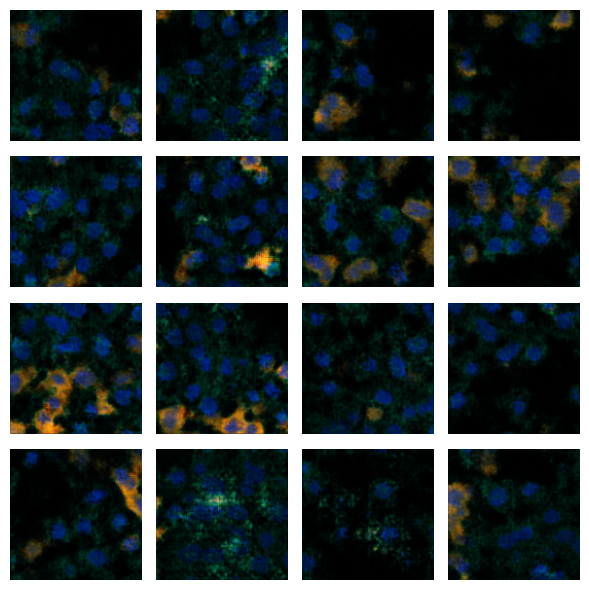


[Snapshot] Saved to epoch_0020.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 164.92 | Precision: 0.593 | Recall: 0.006
  NEW BEST FID! (Improved from inf to 164.92)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 72s 144ms/step - d_loss: -3.1959 - g_loss: -86.7138 - gp: 0.0359 - w_dist: -3.5550
Epoch 21/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - d_loss: -3.2361 - g_loss: -77.5861 - gp: 0.0353 - w_dist: -3.5888
Epoch 22/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -3.2308 - g_loss: -72.4489 - gp: 0.0369 - w_dist: -3.5996
Epoch 23/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -3.2052 - g_loss: -63.1788 - gp: 0.0353 - w_dist: -3.5583
Epoch 24/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -3.1886 - g_loss: -53.2172 - gp: 0.0349 - w_dist: -3.5377
Epoch 25/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -3.1683 - g_loss: -43.4452 - gp: 0.0349 - w_dist: -3.5170
Epoch 26/100
500/500 ━━━━━━━━━━━━━━━━

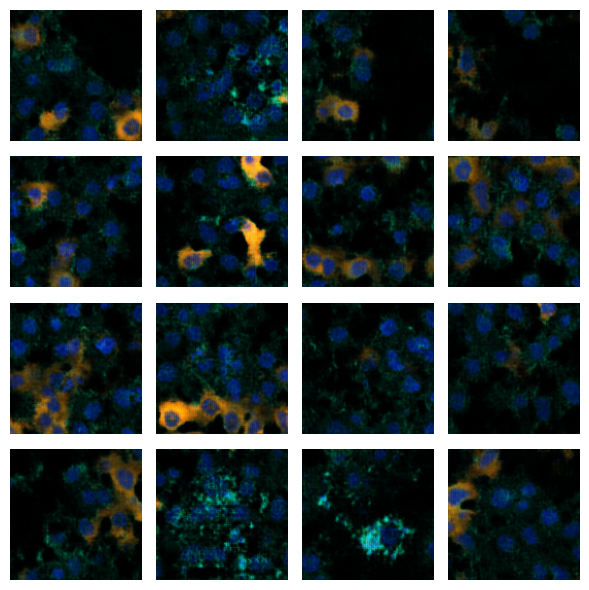


[Snapshot] Saved to epoch_0040.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 112.58 | Precision: 0.823 | Recall: 0.138
  NEW BEST FID! (Improved from 164.92 to 112.58)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - d_loss: -2.6884 - g_loss: -14.9415 - gp: 0.0282 - w_dist: -2.9705
Epoch 41/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 40s 81ms/step - d_loss: -2.6666 - g_loss: -14.4827 - gp: 0.0285 - w_dist: -2.9517
Epoch 42/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -2.6792 - g_loss: -14.6676 - gp: 0.0286 - w_dist: -2.9653
Epoch 43/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -2.7230 - g_loss: -13.6543 - gp: 0.0323 - w_dist: -3.0460
Epoch 44/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -2.6772 - g_loss: -12.3019 - gp: 0.0302 - w_dist: -2.9797
Epoch 45/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - d_loss: -2.6522 - g_loss: -14.5389 - gp: 0.0289 - w_dist: -2.9409
Epoch 46/100
500/500 ━━━━━━━━━━━━━

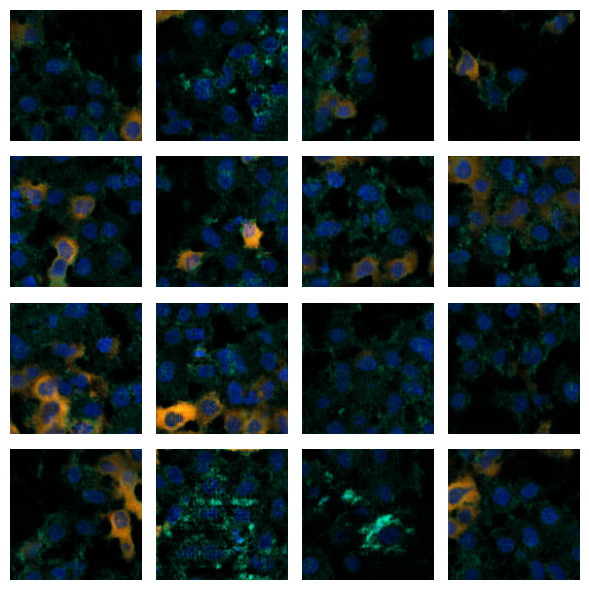


[Snapshot] Saved to epoch_0060.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 92.61 | Precision: 0.894 | Recall: 0.224
  NEW BEST FID! (Improved from 112.58 to 92.61)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 68s 135ms/step - d_loss: -2.3817 - g_loss: -21.0298 - gp: 0.0270 - w_dist: -2.6521
Epoch 61/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 39s 78ms/step - d_loss: -2.4470 - g_loss: -20.4995 - gp: 0.0279 - w_dist: -2.7259
Epoch 62/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - d_loss: -2.4979 - g_loss: -20.5942 - gp: 0.0295 - w_dist: -2.7924
Epoch 63/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.4371 - g_loss: -19.3394 - gp: 0.0261 - w_dist: -2.6980
Epoch 64/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.4383 - g_loss: -20.6168 - gp: 0.0273 - w_dist: -2.7110
Epoch 65/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.3469 - g_loss: -19.9227 - gp: 0.0259 - w_dist: -2.6060
Epoch 66/100
500/500 ━━━━━━━━━━━━━━━

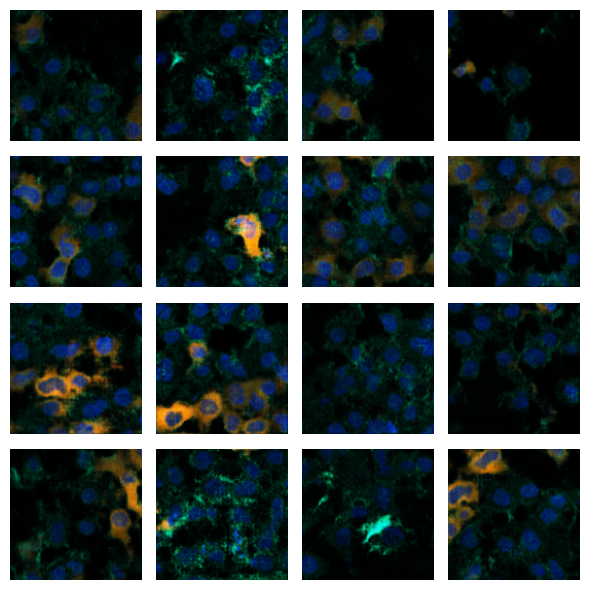


[Snapshot] Saved to epoch_0080.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 78.20 | Precision: 0.939 | Recall: 0.315
  NEW BEST FID! (Improved from 92.61 to 78.20)
  Saving 'generator_best.keras'...
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 139ms/step - d_loss: -2.1247 - g_loss: -11.8785 - gp: 0.0222 - w_dist: -2.3467
Epoch 81/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 37s 74ms/step - d_loss: -2.0897 - g_loss: -12.1443 - gp: 0.0221 - w_dist: -2.3109
Epoch 82/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.1065 - g_loss: -13.4169 - gp: 0.0220 - w_dist: -2.3262
Epoch 83/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.0623 - g_loss: -12.3307 - gp: 0.0228 - w_dist: -2.2901
Epoch 84/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.0328 - g_loss: -12.6763 - gp: 0.0238 - w_dist: -2.2705
Epoch 85/100
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - d_loss: -2.0588 - g_loss: -11.3151 - gp: 0.0238 - w_dist: -2.2972
Epoch 86/100
500/500 ━━━━━━━━━━━━━━━━

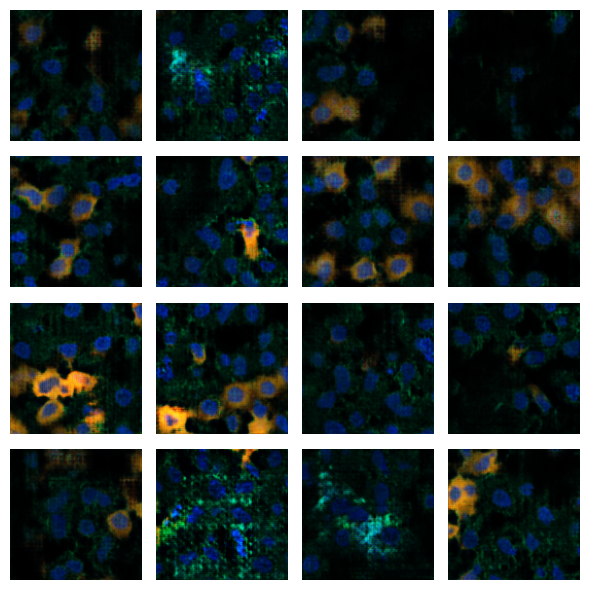


[Snapshot] Saved to epoch_0100.png

[Metrics] Computing FID/Precision/Recall on Validation Set...
 -> FID: 102.47 | Precision: 0.531 | Recall: 0.260
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 141ms/step - d_loss: -0.5069 - g_loss: -100.0241 - gp: 0.0112 - w_dist: -0.6193
Training Completed.


In [ ]:
# Training Execution

# Let's instantiate the callbacks
img_monitor = ImageMonitor(SAMPLE_SAVE_DIR, LATENT_DIM, every=20)

metrics_monitor = GenerativeMetrics(
    val_dataset=val_dataset,            # This uses the validation set
    save_dir=MODEL_SAVE_DIR,
    latent_dim=LATENT_DIM,
    batch_size=BATCH_SIZE,
    every=20,                           # This will calculate metrics every 20 epochs
    num_samples=METRIC_SAMPLE_SIZE      # This is the number of images to be used for FID calculation, and this will be calculated using the dynamic sample size
)

print("WGAN-GP Training in Progress...")

history = wgan.fit(
    train_dataset,  # Training on the 80% split
    epochs=EPOCHS,
    steps_per_epoch=500,
    callbacks=[img_monitor, metrics_monitor]
)

print("Training Completed.")

## Save the final trained models, including the generator, critic, and WGAN-GP weights, to ensure reproducibility and support future inference.

In [ ]:
# Saving the trained Model

wgan.built = True
wgan.generator.save(os.path.join(MODEL_SAVE_DIR, "generator_final.keras"))
wgan.critic.save(os.path.join(MODEL_SAVE_DIR, "critic_final.keras"))
wgan.save_weights(os.path.join(MODEL_SAVE_DIR, "wgan_weights_final.weights.h5"))
print(f"Models saved to {MODEL_SAVE_DIR}")

Models saved to /content/drive/MyDrive/Dataset_v2/Final_Model/WGAN_full_model_v2_n4_subset_1.0


## Perform final validation evaluation by reloading the trained generator and computing FID, Precision, and Recall using the same Inception-based feature pipeline

In [ ]:
# Final Evaluation on Validation Set
eval_gen = tf.keras.models.load_model(os.path.join(MODEL_SAVE_DIR, "generator_final.keras"), compile=False, safe_mode=False)

def calculate_metrics_standalone(generator, eval_dataset, latent_dim, num_samples=1024, batch_size=64):
    print(f"Starting final evaluation on {num_samples} images...")
    inception = get_inception_feature_extractor()

    def get_feats(images):
        return inception(preprocess_for_inception(images), training=False).numpy()

    real_feats_list = []
    count = 0
    # Use the passed evaluation dataset
    for batch in eval_dataset:
        feats = get_feats(batch)
        real_feats_list.append(feats)
        count += feats.shape[0]
        if count >= num_samples:
            break
    real_feats = np.vstack(real_feats_list)[:num_samples]

    fake_feats_list = []
    for i in range(0, num_samples, batch_size):
        z = tf.random.normal([batch_size, latent_dim])
        fake_feats_list.append(get_feats(generator(z, training=False)))
    fake_feats = np.vstack(fake_feats_list)[:num_samples]

    mu1, sigma1 = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean = linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean)

    k = 3
    nn_real = NearestNeighbors(n_neighbors=k).fit(real_feats)
    nn_fake = NearestNeighbors(n_neighbors=k).fit(fake_feats)

    dists_fake_to_real, _ = nn_real.kneighbors(fake_feats)
    dists_real_to_real, _ = nn_real.kneighbors(real_feats)
    manifold_radii = dists_real_to_real[:, -1]
    precision = (dists_fake_to_real[:, 0] <= np.percentile(manifold_radii, 95)).mean()

    dists_real_to_fake, _ = nn_fake.kneighbors(real_feats)
    dists_fake_to_fake, _ = nn_fake.kneighbors(fake_feats)
    manifold_radii_fake = dists_fake_to_fake[:, -1]
    recall = (dists_real_to_fake[:, 0] <= np.percentile(manifold_radii_fake, 95)).mean()

    print(f"\n=== Final Report ===\nFID: {fid:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}")
    return fid, precision, recall

# Calculate metrics using the Validation Dataset
calculate_metrics_standalone(eval_gen, val_dataset, LATENT_DIM, num_samples=METRIC_SAMPLE_SIZE)

Starting final evaluation on 985 images...

=== Final Report ===
FID: 104.5374
Precision: 0.4964
Recall: 0.2883


(np.float64(104.53737673827213),
 np.float64(0.4964467005076142),
 np.float64(0.2883248730964467))

## Visualize training dynamics by plotting generator and discriminator (critic) losses, Wasserstein distance, and gradient penalty across epochs

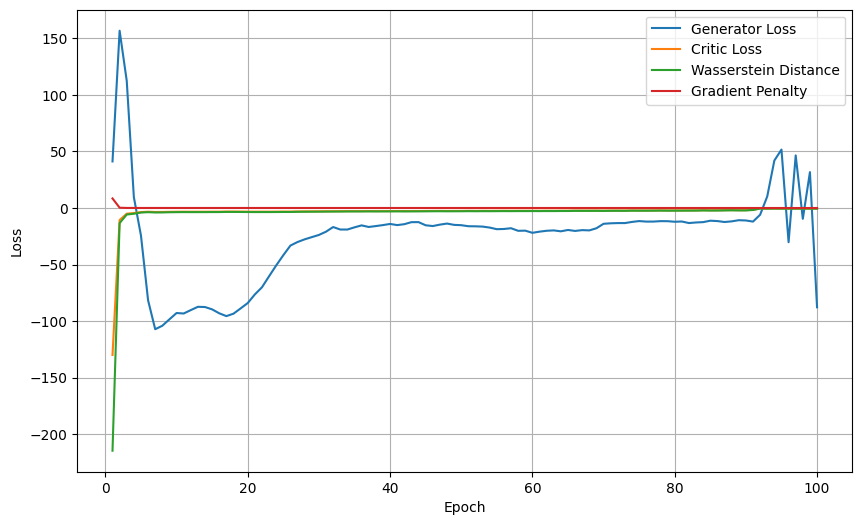

In [ ]:
# Plot Training Curves

plt.figure(figsize=(10, 6))
epochs = range(1, len(history.history["g_loss"]) + 1)

plt.plot(epochs, history.history["g_loss"], label="Generator Loss")
plt.plot(epochs, history.history["d_loss"], label="Critic Loss")
plt.plot(epochs, history.history["w_dist"], label="Wasserstein Distance")
plt.plot(epochs, history.history["gp"], label="Gradient Penalty")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## Visualise a focused, zoomed-in view of training losses over selected epoch range (40-100 epochs).

Plotting zoomed view for epochs 40 to 100


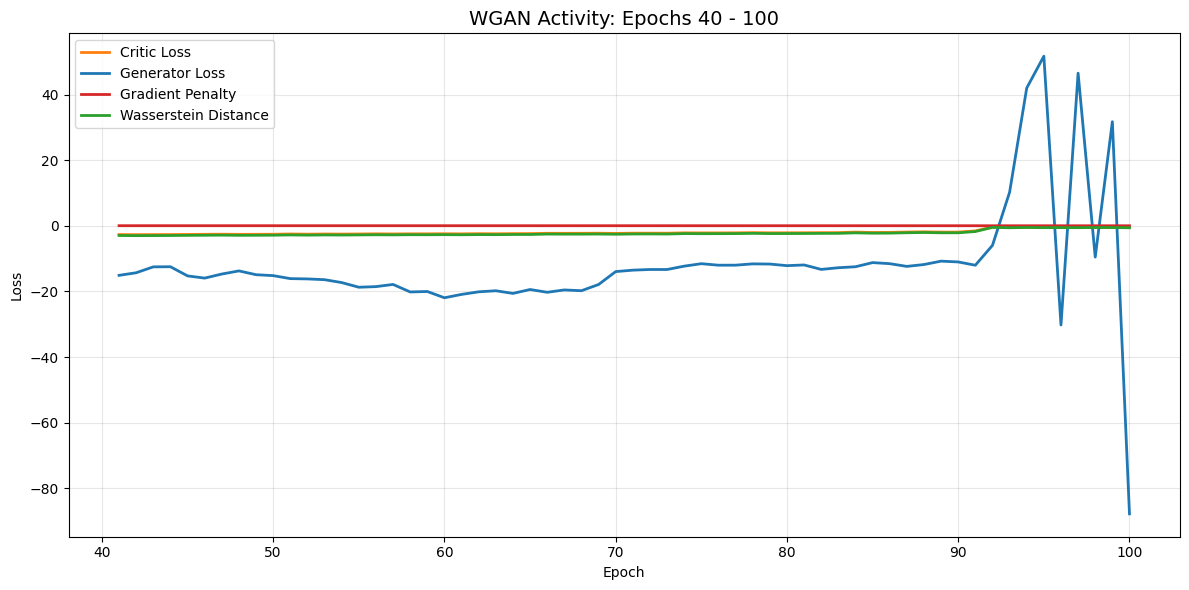

In [ ]:
# Zoomed Loss Visualization
def plot_zoomed_range(history_dict, start_epoch, end_epoch):
    """
    This plots the training history focused on a specific epoch range
    with fixed colors to match the main training graph.
    """

    # Create x-axis values for this specific range
    epochs = range(start_epoch + 1, end_epoch + 1)

    plt.figure(figsize=(12, 6))

    # DEFINE COLOR MAPPING HERE
    # This ensures consistency regardless of loop order
    color_map = {
        "g_loss": "tab:blue",    # Generator: Blue
        "d_loss": "tab:orange",  # Critic/Discriminator: Orange
        "w_dist": "tab:green",   # Wasserstein: Green
        "gp":     "tab:red"      # Gradient Penalty:  Red
    }

    # This maps internal keys to readable labels for the legend
    label_map = {
        "g_loss": "Generator Loss",
        "d_loss": "Critic Loss",
        "w_dist": "Wasserstein Distance",
        "gp":     "Gradient Penalty"
    }

    # Loop through all metrics in the history (Generator Loss, Critic Loss, etc.)
    for metric_name, values in history_dict.items():
        # SLICE the data to get only the part we want
        # Note: Python lists are 0-indexed, so we map epoch 80 to index 79
        subset_values = values[start_epoch:end_epoch]

        # Get the specific color for this metric, default to black if not found
        line_color = color_map.get(metric_name, "black")

        # Get the pretty label, or use the raw key if not found
        line_label = label_map.get(metric_name, metric_name)

        plt.plot(epochs, subset_values, label=line_label, color=line_color, linewidth=2)

    plt.title(f'WGAN Activity: Epochs {start_epoch} - {end_epoch}', fontsize=14)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# CONFIGURATION: This is where we set the zoom range to capture
ZOOM_START_EPOCH = 40
ZOOM_END_EPOCH   = 100

# Logic to handle actual training length
total_epochs_run = len(history.history["g_loss"])

# This clamps the requested start to be valid (must be < total epochs)
zoom_start = max(0, min(ZOOM_START_EPOCH, total_epochs_run - 1))

# This clamps the requested end to be valid (must be <= total epochs)
zoom_end = min(ZOOM_END_EPOCH, total_epochs_run)

print(f"Plotting zoomed view for epochs {zoom_start} to {zoom_end}")

# This allows plotting if there is a valid range
if zoom_end > zoom_start:
    plot_zoomed_range(history.history, start_epoch=zoom_start, end_epoch=zoom_end)
else:
    print(f"Skipping zoomed plot: Training stopped at epoch {total_epochs_run}, before the requested epoch starts {ZOOM_START_EPOCH}.")

## Visualize generative performance by plotting FID alongside Precision and Recall over training epochs

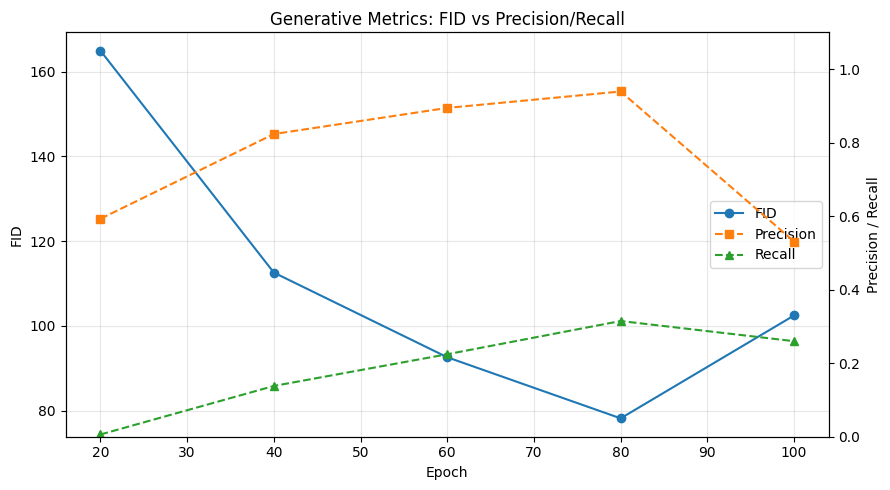

In [ ]:
# Plot FID, Precision, Recall
epochs_eval = [m["epoch"] for m in metrics_monitor.history_records]
fid_vals  = [m["fid"]   for m in metrics_monitor.history_records]
prec_vals = [m["precision"] for m in metrics_monitor.history_records]
rec_vals  = [m["recall"]    for m in metrics_monitor.history_records]

fig, ax1 = plt.subplots(figsize=(9, 5))

# FID (left axis)
ax1.plot(epochs_eval, fid_vals, 'o-', color="tab:blue", label="FID")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("FID")
ax1.grid(True, alpha=0.3)

# Precision/Recall (right axis)
ax2 = ax1.twinx()
ax2.plot(epochs_eval, prec_vals, 's--', color="tab:orange", label="Precision")
ax2.plot(epochs_eval, rec_vals, '^--', color="tab:green", label="Recall")
ax2.set_ylabel("Precision / Recall")
ax2.set_ylim(0, 1.1)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("Generative Metrics: FID vs Precision/Recall")
plt.tight_layout()
plt.show()

## Export recorded FID, Precision, and Recall values to a CSV file for reproducibility and post-training analysis

In [ ]:
# Save Metrics History to CSV
df_metrics = pd.DataFrame(metrics_monitor.history_records)

csv_path = os.path.join(MODEL_SAVE_DIR, "metrics_history.csv")
df_metrics.to_csv(csv_path, index=False)

print("Saved metrics history to:", csv_path)
print(df_metrics.head())

Saved metrics history to: /content/drive/MyDrive/Dataset_v2/Final_Model/WGAN_full_model_v2_n4_subset_1.0/metrics_history.csv
   epoch         fid  precision    recall
0     20  164.917904   0.592893  0.006091
1     40  112.580662   0.823350  0.138071
2     60   92.613444   0.894416  0.224365
3     80   78.204742   0.939086  0.314721
4    100  102.468857   0.530964  0.259898
